In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cvxpy as cp
import time
import pathlib

from modules import power_system_simulation as sim

base_dir = pathlib.Path(".")
system_dir = base_dir / "RTS-GMLC-master" / "RTS_Data"

In [23]:
# 1. Instantiate system
system = sim.System(base_dir, system_dir)

# 2. Read in time series
year = 2006
system.read_timeseries(year)

# 3. Create model
system.write_opf()

In [24]:
### Reliability Simulation ###

# Simulate each day in data set
df_results = pd.DataFrame(index=pd.date_range(f"{year}-01-01 00:00:00", f"{year}-12-31 23:59:59", freq="h"), columns=["Cost", "Unserved Energy"])
df_LMP = pd.DataFrame(index=df_results.index, columns=list(system.nodes.keys()))
start = time.time()
for date in df_results.index[::sim.T]:
    if date + pd.Timedelta(hours=sim.T) > df_results.index.max():
        break
    
    # Re-solve model
    system.solve_opf(date)

    # Save results
    df_results.loc[date, "Cost"] = system.total_variable_costs.value
    df_results.loc[date, "Unserved Energy"] = cp.sum(cp.sum([n.unserved_energy for n in system.nodes.values()])).value
    for n in system.nodes.keys():
        df_LMP.loc[date:date + pd.Timedelta(hours=sim.T-1), n] = system.nodes[n].power_balance_constraint.dual_value
        
        
end = time.time()
time_elapsed = end - start
print(f"Total Elapsed Time: {time_elapsed:.1f}s")

Total Elapsed Time: 46.8s


<Axes: >

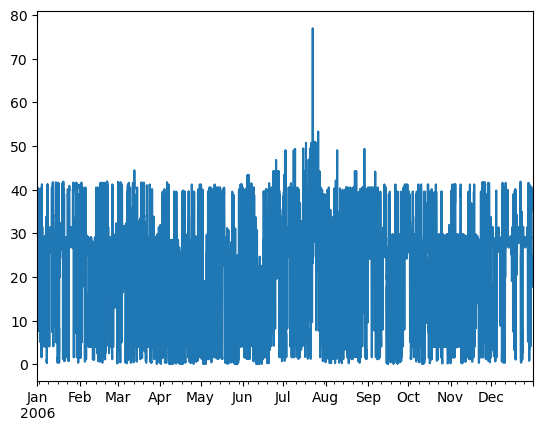

In [25]:
df_LMP[df_LMP.max(axis=0).idxmax()].plot()

<Axes: >

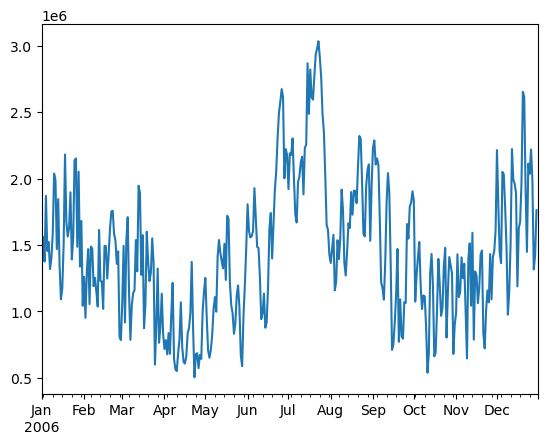

In [26]:
df_results["Cost"][::24].plot()

In [27]:
agg_load = 0
for node in system.nodes.values():
    agg_load += node.peak_load * node.load_profile

<Axes: xlabel='datetime'>

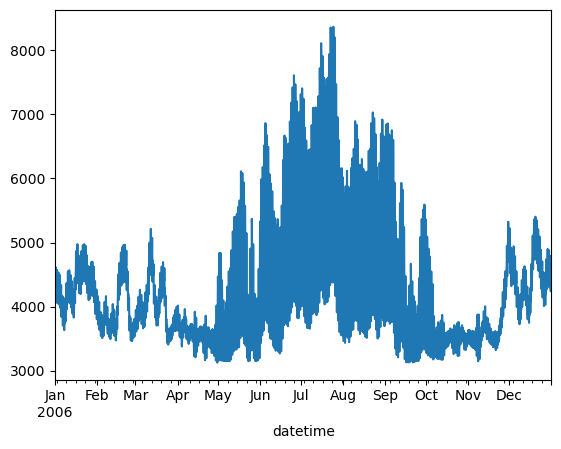

In [28]:
agg_load.plot()

<Axes: xlabel='datetime'>

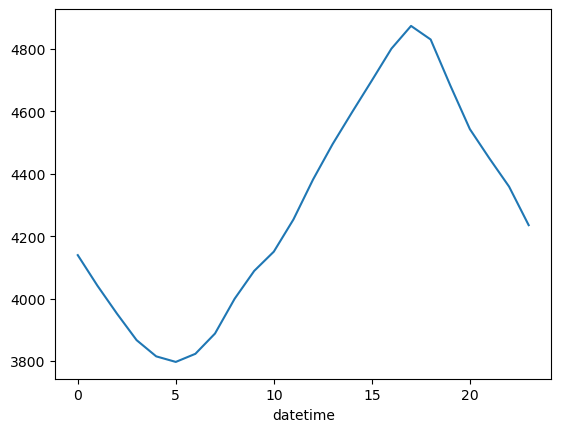

In [29]:
agg_load.groupby(agg_load.index.hour).mean().plot()

In [30]:
for resource in system.variable_resources.values():
    if resource.resource_type == "solar":
        profile = resource.gen_profile
        break

In [31]:
profile

datetime
2006-01-01 00:00:00    0.029613
2006-01-01 01:00:00    0.000000
2006-01-01 02:00:00    0.000000
2006-01-01 03:00:00    0.000000
2006-01-01 04:00:00    0.000000
                         ...   
2006-12-31 19:00:00    0.571975
2006-12-31 20:00:00    0.407009
2006-12-31 21:00:00    0.577546
2006-12-31 22:00:00    0.621339
2006-12-31 23:00:00    0.627544
Name: p_mp, Length: 8760, dtype: float64